In [57]:
movie_id = "5a8413f0-4d4c-4a3c-a08d-9b3787b8244a"

In [58]:
from database.db import supabase
import datetime as dt
from supabase import PostgrestAPIResponse
from database.types import Boxofficeday
from modeling.day_tags import get_adjustment_weight

import matplotlib.pyplot as plt
import seaborn as sns
from typing import TypedDict
from copy import deepcopy
import numpy as np


In [59]:
knn = supabase.rpc("knn", {"movie_id": movie_id, "k": 5}).execute()
# get the boxofficedays and movie info days for the knn
knn_ids = [x["return_id"] for x in knn.data]

knn_boxofficedays: PostgrestAPIResponse[Boxofficeday] = (
    supabase.table("boxofficeday")
    .select("*")
    .in_("movie_id", knn_ids)
    .eq("is_preview", False)
    .order("movie_id")
    .order("date")
    .execute()
)

In [60]:
# for day in knn_boxofficedays.data:
#     day_date = dt.datetime.strptime(day["date"], "%Y-%m-%d").date()
#     adjustment = get_adjustment_weight(day_date)
#     day["revenue"] = day["revenue"] / adjustment

knn_boxoffice: dict[str, list[tuple[dt.date, float]]] = {}

for day in knn_boxofficedays.data:
    day_date = dt.datetime.strptime(day["date"], "%Y-%m-%d").date()
    day_revenue = day["revenue"]

    movie_id = day["movie_id"]

    if movie_id not in knn_boxoffice:
        knn_boxoffice[movie_id] = [(day_date, day_revenue)]
    else:
        knn_boxoffice[movie_id].append((day_date, day_revenue))

# sort the knn boxoffice by date
for knn_id in knn_ids:
    knn_boxoffice[knn_id].sort(key=lambda x: x[0])

# remove all the knn_ids except the first
knn_ids = [knn_ids[0]]

print(f"{knn_ids=}")

knn_ids=['d647bdce-d91a-48e5-a973-53eb83346e54']


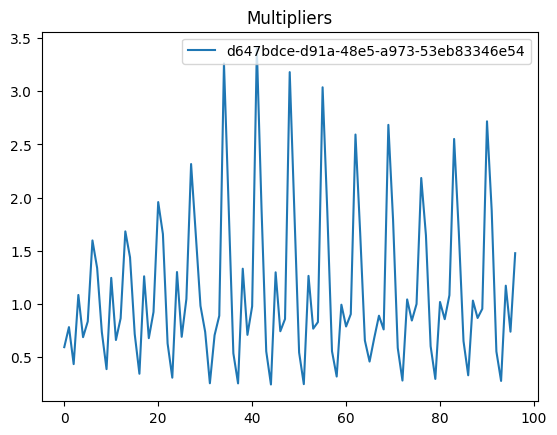

In [61]:
mult_series = {}

for knn_id in knn_ids:
    for i, day in enumerate(knn_boxoffice[knn_id]):
        if i == 0:
            continue
        if knn_id not in mult_series:
            mult_series[knn_id] = [day[1] / knn_boxoffice[knn_id][i - 1][1]]
        else:
            mult_series[knn_id].append(day[1] / knn_boxoffice[knn_id][i - 1][1])

for key, value in mult_series.items():
    plt.plot(range(len(value)), value, label=key)
plt.title("Multipliers")
plt.legend()
plt.show()

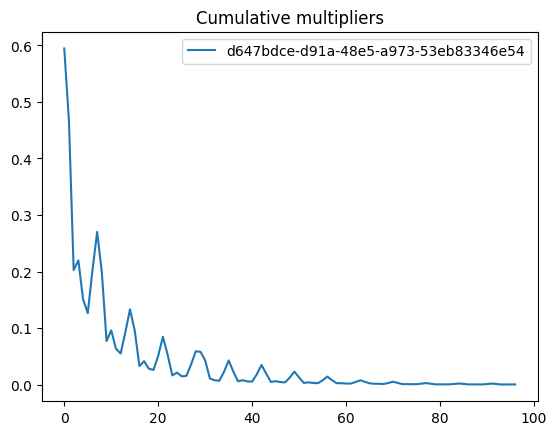

In [62]:
cumulative_mult_products = {}

for knn_id in knn_ids:
    cumulative_mult_products[knn_id] = np.cumprod(mult_series[knn_id])

for key, value in cumulative_mult_products.items():
    plt.plot(range(len(value)), value, label=key)
plt.title("Cumulative multipliers")
plt.legend()
plt.show()

In [63]:
# do the dickey fuller test
from statsmodels.tsa.stattools import adfuller

for knn_id in knn_ids:
    result = adfuller(mult_series[knn_id])
    print(f"{knn_id=}")
    print("ADF Statistic: %f" % result[0])
    print("p-value: %f" % result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print("\t%s: %.3f" % (key, value))

knn_id='d647bdce-d91a-48e5-a973-53eb83346e54'
ADF Statistic: -2.001110
p-value: 0.286087
Critical Values:
	1%: -3.508
	5%: -2.895
	10%: -2.585


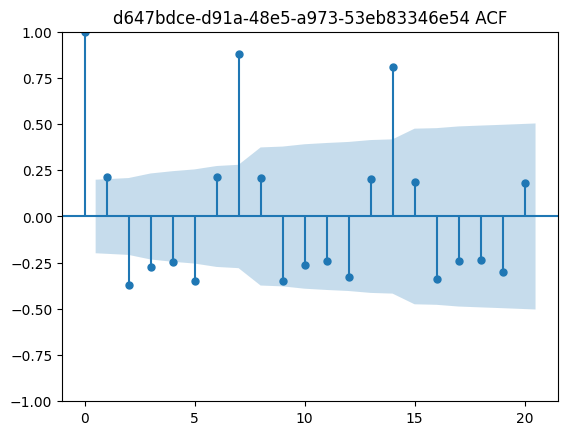

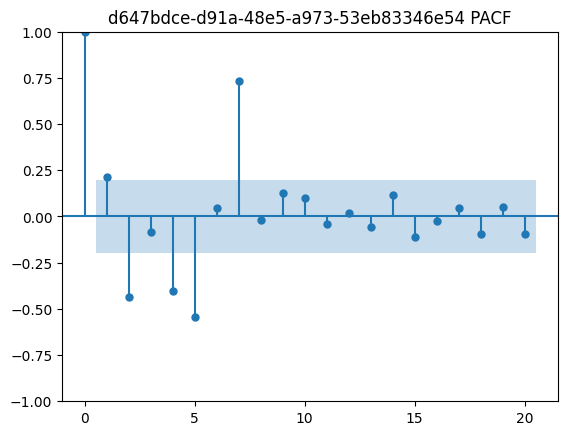

In [64]:
# acf and pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for knn_id in knn_ids:
    plot_acf(np.array(mult_series[knn_id]))
    plt.title(f"{knn_id} ACF")

    plot_pacf(np.array(mult_series[knn_id]))
    plt.title(f"{knn_id} PACF")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   97
Model:                 ARIMA(3, 3, 2)   Log Likelihood                -137.989
Date:                Sat, 22 Feb 2025   AIC                            287.978
Time:                        22:01:30   BIC                            303.238
Sample:                             0   HQIC                           294.142
                                 - 97                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8904      0.479     -1.857      0.063      -1.830       0.049
ar.L2         -0.8168      0.297     -2.754      0.006      -1.398      -0.236
ar.L3         -0.3974      0.269     -1.475      0.1

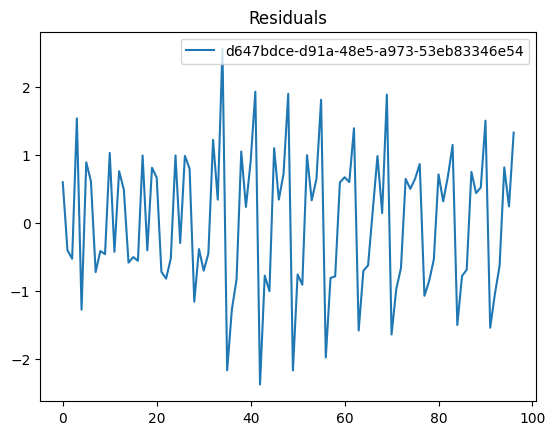

In [68]:
# do an arima on the cumprods
from statsmodels.tsa.arima.model import ARIMA

for knn_id in knn_ids:
    model = ARIMA(mult_series[knn_id], order=(3, 3, 2))
    model_fit = model.fit()
    print(model_fit.summary())

    residuals = model_fit.resid
    plt.plot(range(len(residuals)), residuals, label=knn_id)
plt.title("Residuals")
plt.legend()
plt.show()

                                SARIMAX Results                                
Dep. Variable:                       y   No. Observations:                   97
Model:             SARIMAX(0, 1, 0, 7)   Log Likelihood                  -9.781
Date:                 Sat, 22 Feb 2025   AIC                             21.563
Time:                         22:08:54   BIC                             24.063
Sample:                              0   HQIC                            22.571
                                  - 97                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0728      0.006     13.012      0.000       0.062       0.084
Ljung-Box (L1) (Q):                   1.53   Jarque-Bera (JB):               115.15
Prob(Q):                              0

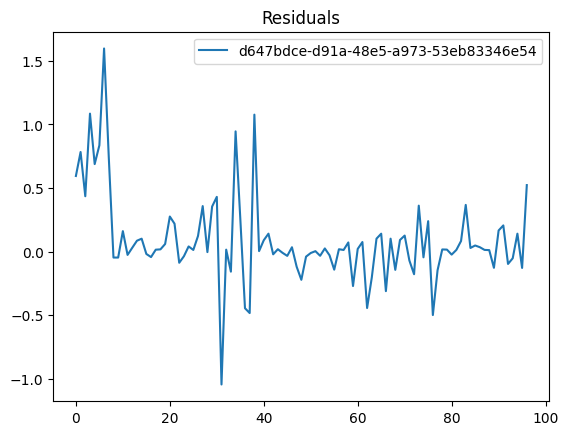

In [114]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

for knn_id in knn_ids:
    model = SARIMAX(mult_series[knn_id], order=(0, 0, 0), seasonal_order=(0, 1, 0, 7))
    model_fit = model.fit()
    print(model_fit.summary())

    residuals = model_fit.resid
    plt.plot(range(len(residuals)), residuals, label=knn_id)
plt.title("Residuals")
plt.legend()
plt.show()

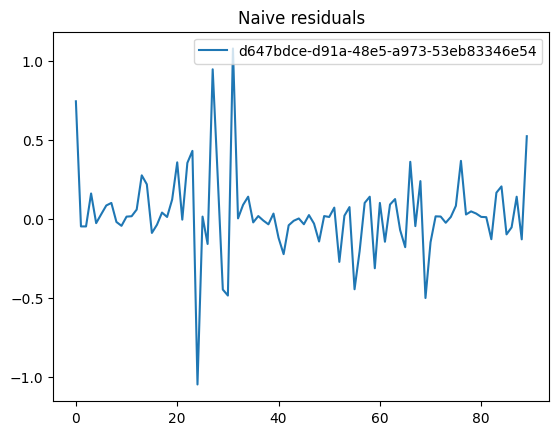

In [67]:
# create the residual of the naive model which is just predicting the value 7 days ago
naive_residuals = []
for knn_id in knn_ids:
    naive_residuals.append(np.array(mult_series[knn_id][7:]) - np.array(mult_series[knn_id][:-7]))

for i, knn_id in enumerate(knn_ids):
    plt.plot(range(len(naive_residuals[i])), naive_residuals[i], label=knn_id)
plt.title("Naive residuals")
plt.legend()